***
# <font color=green size=10>CURSO DE ESTADÍSTICA - PARTE 1</font>
***

## Trabajo de Análisis Descriptivo de un Conjunto de Datos

Utilizando los conocimentos adquiridos en nuestro entrenamiento realice un análisis descriptivo básico del conjunto de datos central que utilizamos durante el curso.

Vamos a construir histogramas, calcular y evaluar medidas de tendencia central, medidas de localización y de dispersión de los datos.

Sige el rutero propuesto y ve completando las células de código vacías. Intenta pensar en Más informaciones interesantes que pueden ser exploradas en nuestro dataset.

# <font color=green>1.1 Dataset del proyecto</font>
***

### Muestra de domicilios Colombia - 2018

Las investigaciones por muestras de domicilios realizadas anualmente, busca encontrar características generales de la población, de educación, trabajo, rendimiento y otras, de acuerdo con las necesidades de información del país, tales como las características de migración, fertilidad, casamientos, salud, nutrición, entre otros temas. Estas muestras al pasar de los años consistuyen una herramienta importante para la formulación, validación y evaluación de políticas dirigidas al desarrollo socioeconómico y la mejora de las condiciones de vida en Colombia.

### Datos

Los datos fueron creados  de manera didáctica para este curso.

### Variables utilizadas

> ### Ingreso
> ***

Ingresos mensuales (en miles de pesos) del trabajo principal para personas de 10 años o más.

> ### Edad
> ***

Edad del entrevistado en la fecha de referencia en años.

> ### Altura
> ***

Altura del entrevistado en metros.

> ### Ciudad
> ***

Código de referência a 27 ciudades analizadas.


> ### Sexo
> ***

|Código|Descripción|
|---|---|
|0|Masculino|
|1|Femenino|

> ### Años de Estudio
> ***

|Código|Descripción|
|---|---|
|1|Sin estudios y menos de 1 año|
|2|1 año|
|3|2 años|
|4|3 años|
|5|4 años|
|6|5 años|
|7|6 años|
|8|7 años|
|9|8 años|
|10|9 años|
|11|10 años|
|12|11 años|
|13|12 años|
|14|13 años|
|15|14 años|
|16|15 años o más|
|17|No se sabe|
||No aplica|

> ### Color
> ***

|Código|Descripción|
|---|---|
|0|Indio|
|2|Blanco|
|4|Negro|
|6|Amarillo|
|8|Moreno|
|9|Sin declarar|

#### Tratamiento a los datos
***

> Algunos de los tratamientos de datos más frecuentes son:
> 1. Eliminar las observaciones (líneas) con entradas de datos inválidos;
> 2. Eliminar observaciones donde hay datos perdidos (missing data);
> 3. Filtros própios de la investigación, por ejemplo: considerar solo las encuestas realizadas a la cabeza de familia (responsable por el domicilio).

***
***

### Utilice la célula abajo para importar las bibliotecas que necesite para ejecutar las tareas
#### <font color='red'>Sugerencias: pandas, numpy, seaborn</font>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Importe el dataset y almacene el contenido en un DataFrame

In [2]:
datos = pd.read_csv('datos.csv')

### Visualice el contenido del DataFrame

In [3]:
datos.head()

,Ciudad,Sexo,Edad,Color,Años de Estudio,Ingreso,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631


### Para evaluar el comportamiento de la variable INGRESO vamos a construir una tabla de frecuencias considerando las siguintes clases según el salário mínimo (SM)
#### <font color='blue'>Descriva los puntos más relevantes que usted observe en la tabla y en el gráfico.</font>

Clases de ingreso:

<b>A</b> ► Más de 25 SM

<b>B</b> ► De 15 a 25 SM

<b>C</b> ► De 5 a 15 SM

<b>D</b> ► De 2 a 5 SM

<b>E</b> ► Hasta 2 SM

Para construir las clases de ingreso considere que el salário mínimo era de <b>$ 788,00</b> miles de pesos colombianos.

#### Siga los pasos abajo:

### 1º Definir los intevalos de las clases

In [11]:
clases = [
    datos.Ingreso.min(),
    2*788,
    5*788,
    15*788,
    25*788,
    datos.Ingreso.max()
]
clases

[0, 1576, 3940, 11820, 19700, 200000]

### 2º Definir los labels de las clases

In [12]:
labels = ['E','D','C','B','A']
labels

['E', 'D', 'C', 'B', 'A']

### 3º Construir la columna de frecuencias

In [14]:
frecuencia = pd.value_counts(
    pd.cut( x = datos.Ingreso,
    bins = clases,
    labels = labels,
    include_lowest = True
  )
)
frecuencia

E    49755
D    18602
C     7241
B      822
A      420
Name: Ingreso, dtype: int64

### 4º Construir la columna de porcentajes

In [15]:
porcentaje = pd.value_counts(
    pd.cut(
    x = datos.Ingreso,
    bins = clases,
    labels = labels,
    include_lowest = True
  ), normalize = True
)* 100
porcentaje

E    64.751432
D    24.208745
C     9.423477
B     1.069755
A     0.546590
Name: Ingreso, dtype: float64

### 5º Juntar las columnas de frecuencias y porcentajes y ordenar las líneas según los labels de las clases

In [16]:
dist_frec_ingreso = pd.DataFrame(
    {'Frecuencia':frecuencia, 'Porcentaje (%)':porcentaje}
    )
dist_frec_ingreso.sort_index(ascending=False)

,Frecuencia,Porcentaje (%)
A,420,0.546590
B,822,1.069755
C,7241,9.423477
D,18602,24.208745
E,49755,64.751432


### Construya um gráfico de barras para visualizar las informaciones de la tabla de frecuencias de arriba

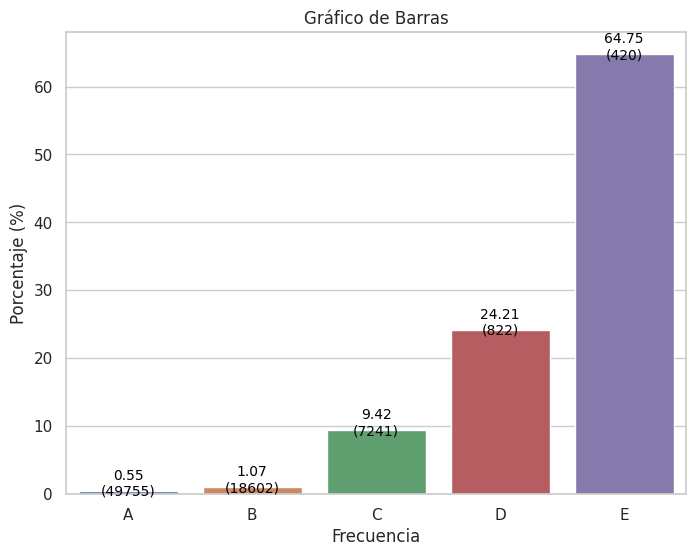

In [23]:
# Configurar el estilo de Seaborn (opcional)
sns.set(style="whitegrid")

# Crear el gráfico de barras
plt.figure(figsize=(8, 6))  # Opcional: ajusta el tamaño del gráfico
ax = sns.barplot(x="Frecuencia", y="Porcentaje (%)", data=dist_frec_ingreso)

# Personalizar el gráfico (opcional)
plt.title("Gráfico de Barras")
plt.xlabel("Frecuencia")
plt.ylabel("Porcentaje (%)")

# Agregar etiquetas de frecuencia en las barras
for i, p in enumerate(ax.patches):
    ax.annotate(
        f"{p.get_height():.2f}\n({frecuencia.iloc[i]})",
         (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', fontsize=10, color='black',
        xytext=(0, 5), textcoords='offset points')

# Personalizar las etiquetas de las barras
labels = ["A", "B", "C", "D", "E"]
ax.set_xticklabels(labels)

# Mostrar el gráfico
plt.show()


> ### **Conclusiones**

**Extrema desigualdad:** Esta estadística subraya una extrema desigualdad en la distribución de ingresos en Colombia. Mientras que un pequeño porcentaje de la población disfruta de ingresos significativamente más altos, la gran mayoría lucha por ganar un salario apenas superior al mínimo necesario para satisfacer sus necesidades básicas.

**Necesidad de políticas de equidad:** La brecha entre el 0.26% y el 70% en términos de ingresos sugiere la urgencia de implementar políticas que busquen reducir la desigualdad económica en el país. Esto podría incluir medidas como aumentar el salario mínimo, mejorar la educación y el acceso a oportunidades laborales, y abordar otras fuentes de desigualdad.

**Dificultades económicas para la mayoría:** Para la mayoría de la población que gana un salario apenas superior al mínimo, esta situación podría significar dificultades para cubrir gastos esenciales, acceder a atención médica adecuada y mejorar su calidad de vida. Esto destaca la importancia de abordar la falta de oportunidades y la insuficiencia de los ingresos.

**Necesidad de datos detallados:** Para comprender completamente la situación económica y social en Colombia, se necesitarían datos más detallados y análisis adicionales que consideren factores como la ubicación geográfica, la educación y la industria laboral. Estos factores pueden tener un impacto significativo en la distribución de ingresos.

### Cree un histograma para las variables QUANTITATIVAS de nuestro dataset
#### <font color='blue'>Descriva los puntos más relevantes que usted observa en los gráficos (asimetrías y sus tipos, posibles causas para determinados comportamientos etc.)</font>

* **Simetrica**

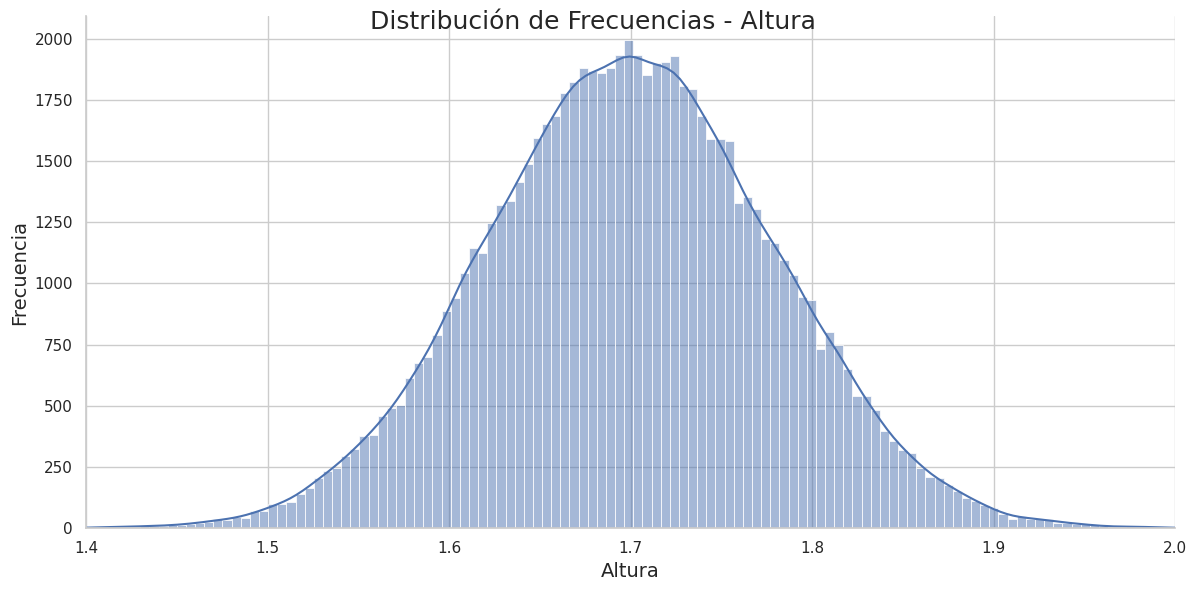

In [37]:
# Crear el gráfico de distribución de frecuencias
ax = sns.displot(data=datos, x='Altura', kde=True, height=6, aspect=2)
ax.set_axis_labels("Altura", "Frecuencia")
ax.fig.suptitle("Distribución de Frecuencias - Altura", fontsize=18)

# Personalizar el estilo del gráfico
sns.set(style="whitegrid")

# Establecer límites en el eje x
ax.set(xlim=(1.4, 2))

# Añadir título y etiquetas de ejes
ax.set_titles(fontsize=18)
ax.set_xlabels("Altura", fontsize=14)
ax.set_ylabels("Frecuencia", fontsize=14)

# Mostrar el gráfico
plt.show()

* **Simetrica**

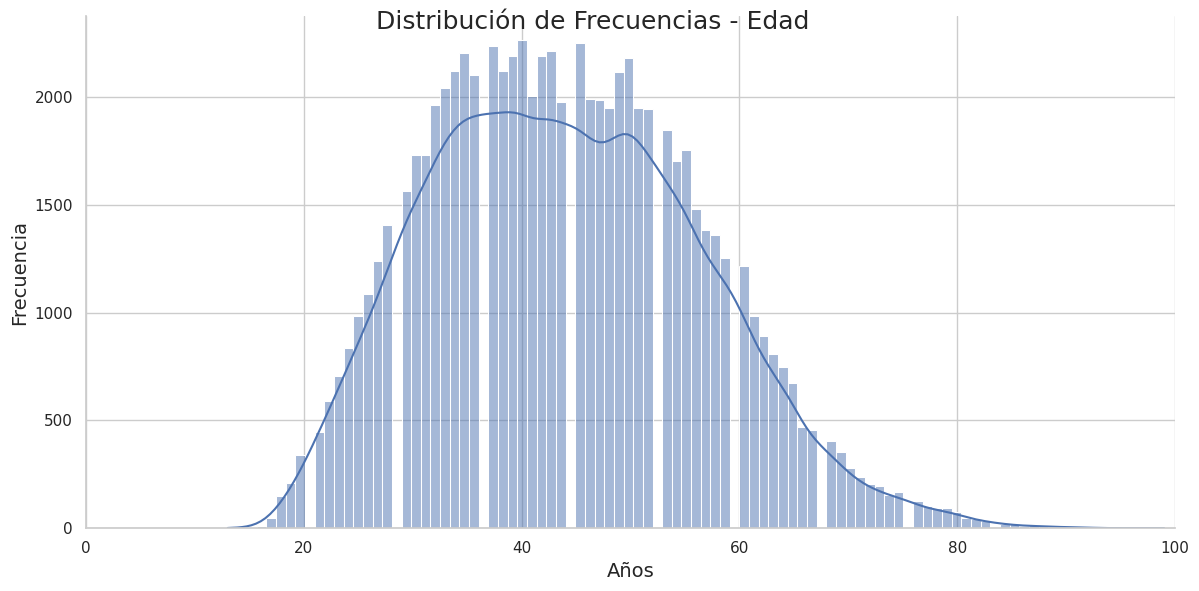

In [26]:
# Crear el gráfico de distribución de frecuencias
ax = sns.displot(data=datos, x='Edad', kde=True, height=6, aspect=2)
ax.set_axis_labels("Años", "Frecuencia")
ax.fig.suptitle("Distribución de Frecuencias - Edad", fontsize=18)

# Personalizar el estilo del gráfico
sns.set(style="whitegrid")
ax.set(xlim=(0, 100))  # Establecer límites del eje x si es necesario

# Añadir título y etiquetas de ejes
ax.set_titles(fontsize=18)
ax.set_xlabels(fontsize=14)
ax.set_ylabels(fontsize=14)

# Mostrar el gráfico
plt.show()

* **Asimetrica a la derecha**

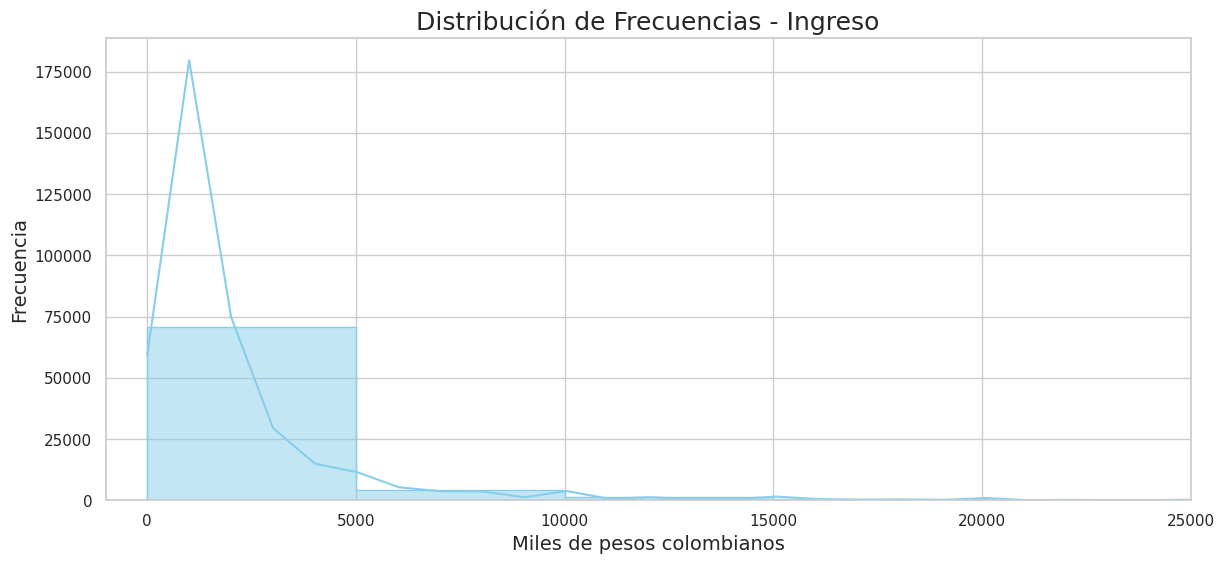

In [48]:
# Crear el gráfico de barras de distribución de frecuencias
plt.figure(figsize=(14, 6))
sns.histplot(data=datos, x='Ingreso', bins=40, kde=True, color='skyblue', element='step')
plt.title('Distribución de Frecuencias - Ingreso', fontsize=18)
plt.xlabel('Miles de pesos colombianos', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)

# Establecer límites en el eje x
plt.xlim(-1000,25000)

# Personalizar el estilo del gráfico
sns.set(style="whitegrid")

# Mostrar el gráfico
plt.show()

> ### **Conclusiones**

1. **Simetrica**
* La variable "Altura" podría estar distribuida de manera aproximadamente normal, con una media y una desviación estándar que definen la forma de la curva de campana.

2. **Simetrica:**
* Las edades están distribuidas de manera uniforme a ambos lados de la media, lo que sugiere que no hay una tendencia clara hacia edades más jóvenes o más viejas en la muestra.
3. **Asimetrica a la derecha:**
* Esto podría indicar que la mayoría de las personas tienen ingresos relativamente bajos, pero hay un pequeño número de personas con ingresos muy altos que están inflando la cola derecha de la distribución.

### Para la variable INGRESO, construya un histograma solamente con las informaciones de las personas con rendimento hasta $ 20.000,00 (miles de pesos).

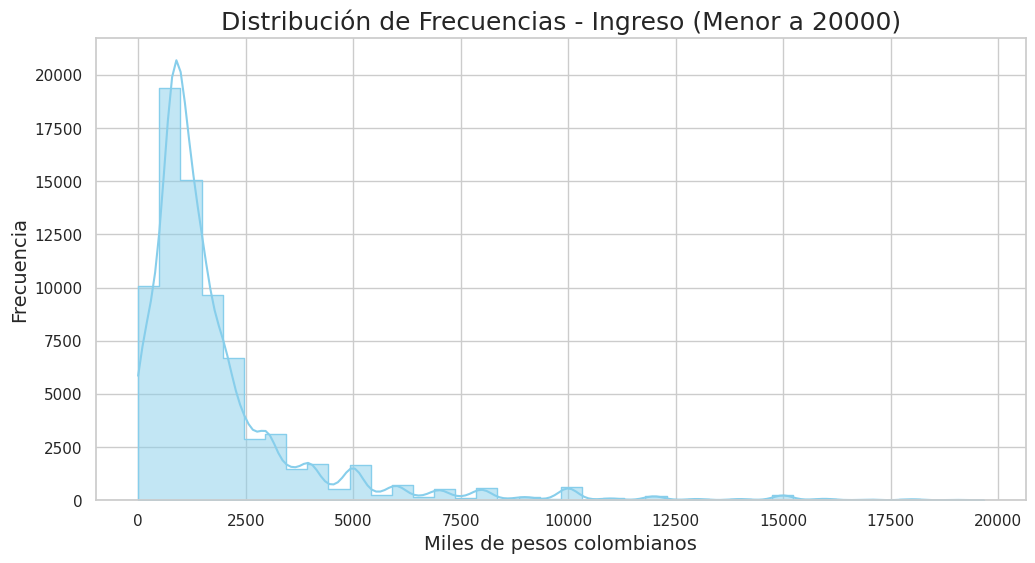

In [49]:
# Filtrar datos para ingresos menores a 20000
ingresos_filtrados = datos.query('Ingreso < 20000')['Ingreso']

# Crear el gráfico de distribución de frecuencias
plt.figure(figsize=(12, 6))
sns.histplot(ingresos_filtrados, bins=40, kde=True, color='skyblue', element='step')
plt.title('Distribución de Frecuencias - Ingreso (Menor a 20000)', fontsize=18)
plt.xlabel('Miles de pesos colombianos', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)

# Personalizar el estilo del gráfico
sns.set(style="whitegrid")


# Mostrar el gráfico
plt.show()

### Construya una tabla de frecuencias y una con los porcentajes cruzando las variables SEXO y COLOR
#### <font color='blue'>Evalue el resultado de la tabla y escriva sus conclusiones principales</font>
#### <font color='red'>Utilize los diccionarios abajo para renombrar las líneas y columnas de las tablas de frecuencias y de los gráficos en nuestro proyecto</font>

In [85]:
sexo = {
    0: 'Masculino',
    1: 'Femenino'
}
color = {0: 'Indio',
         2: 'Blanco',
         4: 'Negro',
         6: 'Amarillo',
         8: 'Pardo',
         9: 'Sin declarar'}
anos_de_estudio = {
    1: 'Sin estudios y menos de 1 año',
    2: '1 año',
    3: '2 años',
    4: '3 años',
    5: '4 años',
    6: '5 años',
    7: '6 años',
    8: '7 años',
    9: '8 años',
    10: '9 años',
    11: '10 años',
    12: '11 años',
    13: '12 años',
    14: '13 años',
    15: '14 años',
    16: '15 años ou más',
    17: 'No se sabe'
}

In [52]:
frecuencia = pd.crosstab(datos.Sexo,
                         datos.Color
                         )
frecuencia.rename(index = sexo, inplace = True)
frecuencia.rename(columns = color, inplace = True)
frecuencia

Color,Indio,Blanco,Negro,Amarillo,Pardo
Sexo,,,,,
Masculino,256,22194,5502,235,25063
Femenino,101,9621,2889,117,10862


> ### **Conclusiones**

1. **Distribución de género:** Hay una clara diferencia en la distribución de género en los grupos raciales. En ambos grupos raciales, el número de personas de género masculino es significativamente mayor que el número de personas de género femenino.

2. **Mayoría en el grupo Blanco:** El grupo racial "Blanco" tiene la mayor cantidad de personas tanto en la categoría masculina como en la femenina. Esto sugiere que la población blanca es la más numerosa en el conjunto de datos.

3. **Baja representación en el grupo Amarillo:** El grupo racial "Amarillo" tiene la menor cantidad de personas en ambas categorías de género. Esto indica una menor representación de este grupo racial en la población.

4. **Diferencias en la distribución racial:** La distribución racial varía significativamente entre los grupos raciales. Por ejemplo, en el grupo "Indio", la mayoría de las personas son de género masculino, mientras que en el grupo "Negro" y "Amarillo", la mayoría son de género femenino.

## Realize, para la variable INGRESO, un análisis descriptivo con las herramientas que aprendimos en nuestro entrenamiento.

### Obtenga la media aritmética

In [54]:
datos.Ingreso.mean()

2000.3831988547631

### Obtenga la mediana

In [55]:
datos.Ingreso.median()

1200.0

### Obtenga la moda

In [56]:
datos.Ingreso.mode()

0    788
Name: Ingreso, dtype: int64

### Obtenga la desviación media absoluta

In [59]:
datos.Ingreso.mad()

<ipython-input-59-1ddc9cda72c3>:1: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  datos.Ingreso.mad()


1526.4951371638058

### Obtenga la varianza

In [58]:
datos.Ingreso.var()

11044906.006217021

### Obtenga la desviación estandar

In [60]:
datos.Ingreso.std()

3323.3877303464037

### Obtenga la media, mediana y valor máximo de la variable INGRESO según el SEXO y el COLOR
#### <font color='blue'>Destaque los puntos más importantes que usted observa en las tabulaciones</font>
#### <font color='red'>El parámetro <i>aggfunc</i> de la función <i>crosstab()</i> puede recibir una lista de funciones. Ejemplo: <i>aggfunc = {'mean', 'median', 'max'}</i></font>

In [62]:
ingreso_sexo_color = pd.crosstab(datos.Color,
                                 datos.Sexo,
                                 values = datos.Ingreso,
                                 aggfunc={'mean','median','max'})
ingreso_sexo_color.rename(index = color,inplace=True)
ingreso_sexo_color.rename(columns = sexo,inplace=True)
ingreso_sexo_color

max                  mean                 median         
Sexo     Masculino Femenino    Masculino     Femenino Masculino Femenino
Color                                                                   
Indio        10000   120000  1081.710938  2464.386139     797.5    788.0
Blanco      200000   100000  2925.744435  2109.866750    1700.0   1200.0
Negro        50000    23000  1603.861687  1134.596400    1200.0    800.0
Amarillo     50000    20000  4758.251064  3027.341880    2800.0   1500.0
Pardo       100000    30000  1659.577425  1176.758516    1200.0    800.0

> ### **Conclusiones**

Los ingresos máximos son más altos en el grupo "Blanco", mientras que los grupos "Negro" y "Amarillo" tienden a tener ingresos máximos más bajos. Sin embargo, es importante recordar que estos valores son estadísticas resumidas y no capturan la diversidad y la variabilidad en los ingresos dentro de cada grupo. Las diferencias en los ingresos pueden estar influenciadas por una variedad de factores socioeconómicos y demográficos.






### Obtenga las medidas de dispersión de la variable INGRESO según el SEXO y el COLOR
#### <font color='blue'>Destaque los puntos más importantes que usted observa en las tabulaciones</font>
#### <font color='red'>O parámetro <i>aggfunc</i> de la función <i>crosstab()</i> puede reciber una lista de funciones. Ejemplo: <i>aggfunc = {'mad', 'var', 'std'}</i></font>

In [78]:
ingreso_sexo_color = pd.crosstab(datos.Color,
                                 datos.Sexo,
                                 values = datos.Ingreso,
                                 aggfunc={'mad','var','std'})
ingreso_sexo_color.rename(index = color,inplace=True)
ingreso_sexo_color.rename(columns = sexo,inplace=True)
ingreso_sexo_color

<ipython-input-78-df4a2f8f5a22>:1: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  ingreso_sexo_color = pd.crosstab(datos.Color,
<ipython-input-78-df4a2f8f5a22>:1: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  ingreso_sexo_color = pd.crosstab(datos.Color,
<ipython-input-78-df4a2f8f5a22>:1: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  ingreso_sexo_color = pd.crosstab(datos.Color,
<ipython-input-78-df4a2f8f5a22>:1: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  ingreso_sexo_color = pd.crosstab(datos.Color,
<ipython-input-78-df4a2f8f5a22>:

mad                       std                         var  \
Sexo        Masculino     Femenino    Masculino      Femenino     Masculino   
Color                                                                         
Indio      798.910889  3007.892952  1204.093490  11957.498292  1.449841e+06   
Blanco    2261.012346  1670.967106  4750.791872   3251.013154  2.257002e+07   
Negro      975.602482   705.453357  1936.309271   1349.799809  3.749294e+06   
Amarillo  3709.597211  2549.146322  5740.824820   3731.173660  3.295707e+07   
Pardo     1125.827704   811.580946  2312.087184   1596.233048  5.345747e+06   

                        
Sexo          Femenino  
Color                   
Indio     1.429818e+08  
Blanco    1.056909e+07  
Negro     1.821960e+06  
Amarillo  1.392166e+07  
Pardo     2.547960e+06

> ### **Conclusiones**

los valores de desviación estándar y varianza son más altos en el género masculino en varios grupos raciales, lo que sugiere que los ingresos de los hombres tienden a estar más dispersos que los ingresos de las mujeres en estos grupos.

### Construya um box plot de la variable INGRESO según SEXO y COLOR
#### <font color='blue'>¿Es posible verificar algún comportamiento diferenciado en el rendimiento entre los grupos de personas analizados? Evalue el gráfico y destaque los puntos más importantes.</font>
#### <font color='red'>1º - Utilice solamente las informaciones de personas con ingreso abajo de $ 10.000</font>
#### <font color='red'>2º - Para incluir una tercera variable en la construcción de un boxplot utilice el parámetro <i>hue</i> e indique la variable que quiere incluir en la subdivisión.</font>
#### Más informaciones: https://seaborn.pydata.org/generated/seaborn.boxplot.html

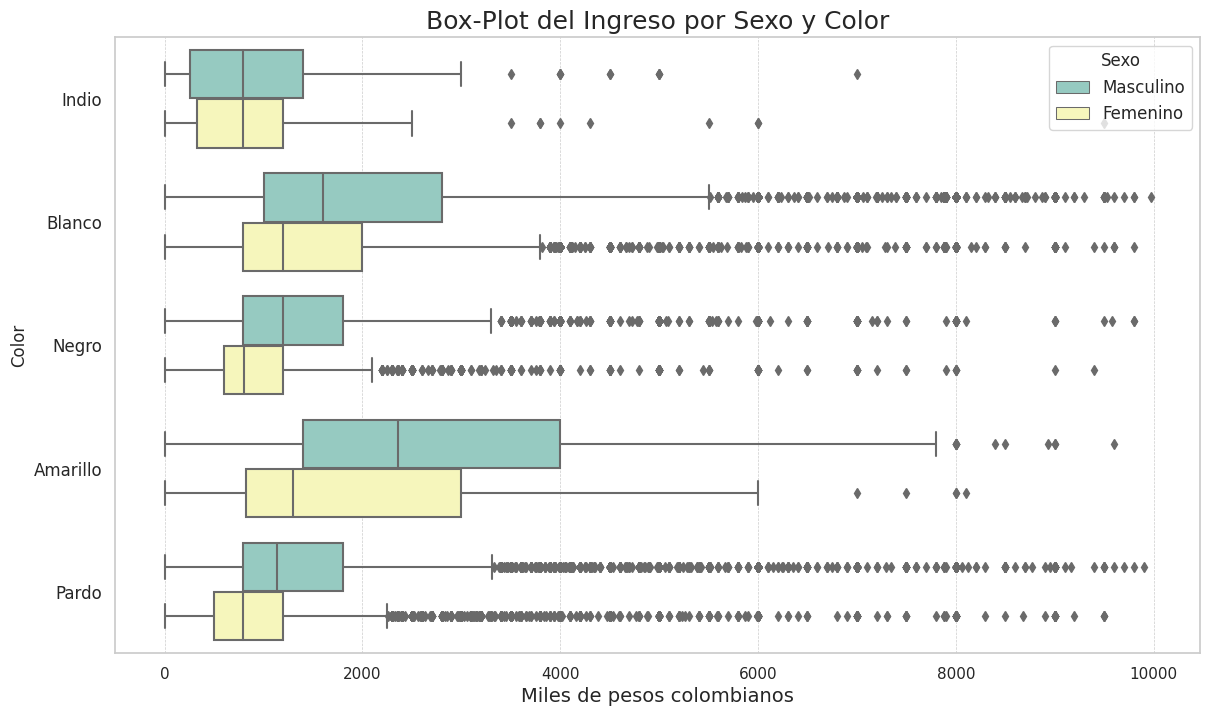

In [70]:
# Filtrar datos para ingresos menores a 10,000
datos_filtrados = datos.query('Ingreso < 10000')

# Crear el gráfico de caja
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='Ingreso', y='Color', hue='Sexo', data=datos_filtrados, orient='h', palette="Set3")
ax.set_title('Box-Plot del Ingreso por Sexo y Color', fontsize=18)
ax.set_xlabel('Miles de pesos colombianos', fontsize=14)
ax.set_yticklabels(['Indio', 'Blanco', 'Negro', 'Amarillo', 'Pardo'], fontsize=12)

# Personalizar la leyenda
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Masculino', 'Femenino'], title='Sexo', title_fontsize=12, fontsize=12)

# Añadir líneas de cuadrícula horizontal
ax.grid(axis='x', linestyle='--', linewidth=0.5)

# Mostrar el gráfico
plt.show()


### <font color='red' size = 10> DESAFÍO

### ¿Cuál es el porcentaje de personas de nuestro <i>dataset</i> que ganan un salário mínimo ($ 788,00) o menos?
#### <font color='red'>Utilize la función <i>percentileofscore()</i> do <i>scipy</i> para realizar estos análisis.</font>
#### Más informaciones: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.percentileofscore.html


In [73]:
from scipy import stats

porcentaje = stats.percentileofscore(datos.Ingreso,788,kind='weak')
print('{0:.2f}%'.format(porcentaje))

28.87%


### ¿Cuál es el valor máximo ganado por 99% de las personas de nuestro <i>dataset</i>?
#### <font color='red'>Utilice el método <i>quantile()</i> de <i>pandas</i> para realizar estos análisis.</font>

In [77]:
valor = datos.Ingreso.quantile(.99)
print('$ {0:.2f}'.format(valor))

$ 15000.00


### Obtenga la media, mediana, valor máximo y desviación estandar de la variable INGRESO según AÑOS DE ESTUDIO y SEXO
#### <font color='blue'>Destaque los puntos más importantes que usted observa en las Tabulaciones</font>
#### <font color='red'>O parámetro <i>aggfunc</i> de la función <i>crosstab()</i> puede recibir una lista de funciones. Ejemplo: <i>aggfunc = ['mean', 'median', 'max', 'std']</i></font>

In [79]:
ingreso_sexo_estudio = pd.crosstab(datos['Años de Estudio'],
                                 datos.Sexo,
                                 aggfunc={'mean','median','max','std'},
                                   values=datos.Ingreso).round(2)
ingreso_sexo_estudio.rename(index = anos_de_estudio,inplace=True)
ingreso_sexo_estudio.rename(columns = sexo,inplace=True)
ingreso_sexo_estudio

max               mean             median  \
Sexo                          Masculino Femenino Masculino Femenino Masculino   
Años de Estudio                                                                 
Sin estudios y menos de 1 año     30000    10000    799.49   516.20     700.0   
1 año                             30000     2000    895.63   492.77     788.0   
2 años                            40000     4000    931.18   529.91     788.0   
3 años                            80000     3500   1109.20   546.85     800.0   
4 años                            50000    10000   1302.33   704.28    1000.0   
5 años                            35000     8000   1338.65   781.39    1045.0   
6 años                            25000     6000   1448.88   833.73    1200.0   
7 años                            40000     9000   1465.50   830.75    1200.0   
8 años                            30000    18000   1639.40   933.62    1300.0   
9 años                            60000    20000   1508.04   868.02    1200.0   
10 años                           45000     6000   1731.27   925.92    1218.0   
11 años                          200000   100000   2117.06  1286.79    1500.0   
12 años                           30000   120000   2470.33  1682.31    1800.0   
13 años                           25000    20000   3195.10  1911.73    2400.0   
14 años                           50000    20000   3706.62  2226.46    2500.0   
15 años ou más                   200000   100000   6134.28  3899.51    4000.0   
No se sabe                         7000     3000   1295.76   798.17    1200.0   

                                             std           
Sexo                          Femenino Masculino Femenino  
Años de Estudio                                            
Sin estudios y menos de 1 año    390.0   1023.90   639.31  
1 año                            400.0   1331.95   425.29  
2 años                           450.0   1435.17   498.23  
3 años                           500.0   2143.80   424.12  
4 años                           788.0   1419.82   629.55  
5 años                           788.0   1484.65   635.78  
6 años                           788.0   1476.63   574.55  
7 años                           788.0   1419.71   602.04  
8 años                           800.0   1515.58   896.78  
9 años                           788.0   2137.66   973.22  
10 años                          800.0   2078.61   620.61  
11 años                         1000.0   2676.54  1819.04  
12 años                         1200.0   2268.08  4851.83  
13 años                         1300.0   2797.12  2053.79  
14 años                         1600.0   3987.21  2064.08  
15 años ou más                  2800.0   7447.61  4212.77  
No se sabe                       788.0    979.65   459.99

### Construya un box plot de la variable INGRESO según AÑOS DE ESTUDIO y SEXO
#### <font color='blue'>¿Es posible verificar algun comportamiento diferenciado en el rendimiento entre los grupos de personas analizadas? Evalue el gráfico y destaque los puntos más importantes.</font>
#### <font color='red'>1º - Utilice solamente las informaciones de personas com ingreso abajo de $ 10.000</font>
#### <font color='red'>2º - Utilice la variable EDAD para identificar si la desigualdad se verifica para personas de la mesma edad. Ejemplo: <i>data=datos.query('Ingreso < 10000 and Edad == 40')</i> ou <i>data=datos.query('Ingreso < 10000 and Edad == 50')</i></font>
#### <font color='red'>3º - Para incluir una tercera variable en la construcción de un boxplot utilice el parámetro <i>hue</i> e indique la variable que quiere incluir en la subdivisión.</font>
#### Más informaciones: https://seaborn.pydata.org/generated/seaborn.boxplot.html

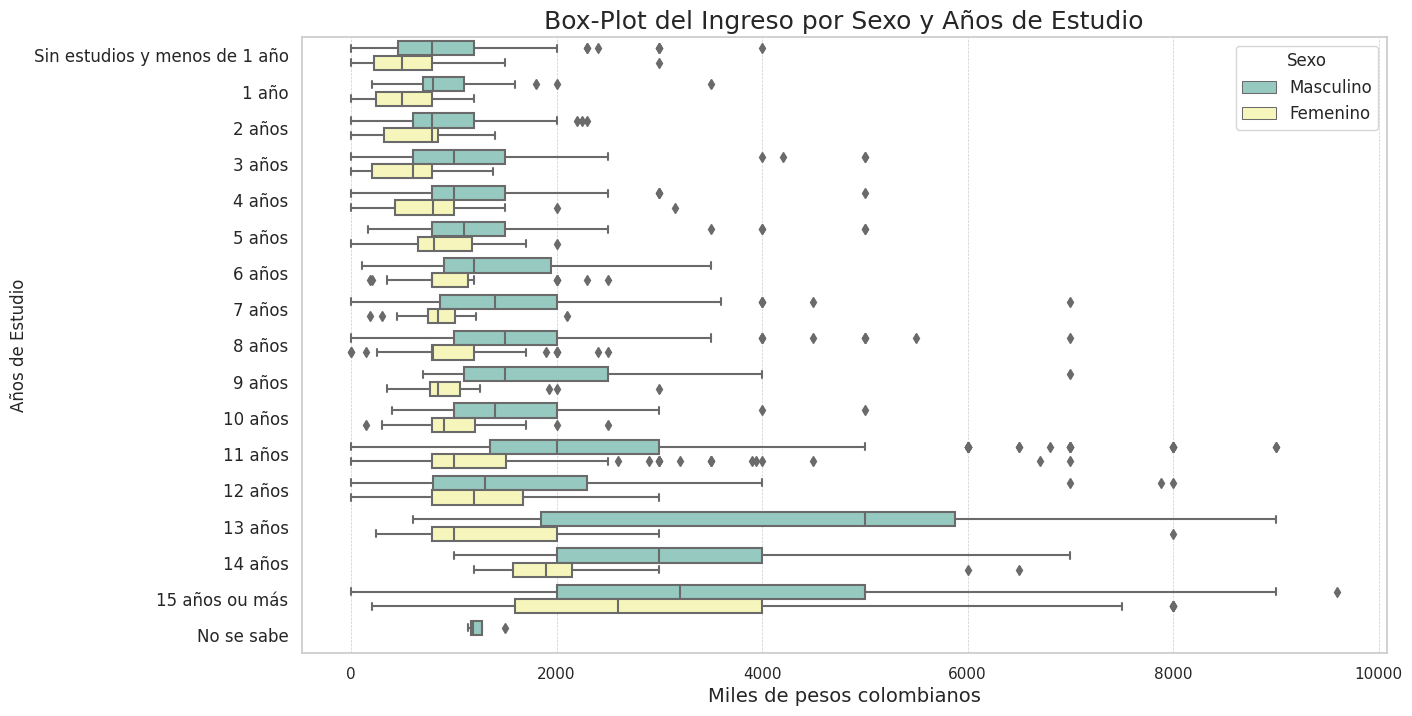

In [87]:
# Filtrar datos para ingresos menores a 10,000 y edad igual a 50
datos_filtrados = datos.query('Ingreso < 10000 and Edad == 50')

# Crear el gráfico de caja
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='Ingreso', y='Años de Estudio', hue='Sexo', data=datos_filtrados, orient='h', palette="Set3")
ax.set_title('Box-Plot del Ingreso por Sexo y Años de Estudio', fontsize=18)
ax.set_xlabel('Miles de pesos colombianos', fontsize=14)
ax.set_ylabel('Años de Estudio', fontsize=12)

# Personalizar las etiquetas del eje y
ax.set_yticklabels([key for key in anos_de_estudio.values()], fontsize=12)

# Personalizar la leyenda
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Masculino', 'Femenino'], title='Sexo', title_fontsize=12, fontsize=12)

# Añadir líneas de cuadrícula horizontal
ax.grid(axis='x', linestyle='--', linewidth=0.5)

# Mostrar el gráfico
plt.show()

### Obtenga la media, mediana, valor máximo y  desviación estandar de la variable INGRESO según las CIUDADES
#### <font color='blue'>Destaque los puntos más importantes que usted observa en las tabulaciones</font>
#### <font color='red'>Utilice el método <i>groupby()</i> de <i>pandas</i> conjuntamente com el método <i>agg()</i> para contruir la tabulación. El método <i>agg()</i> puede recibir un diccionario especificando cual columna del DataFrame deve ser utilizada y cual lista de funciones estadísticas queremos obtener, por ejemplo: <i>datos.groupby(['Ciudad']).agg({'Ingreso': ['mean', 'median', 'max', 'std']})</i></font>

In [88]:
ingreso_ciudades = datos.groupby(['Ciudad']).agg({'Ingreso': ['mean','median','max','std']})
ingreso_ciudades

Ingreso                             
               mean  median     max          std
Ciudad                                          
11      1789.761223  1200.0   50000  2406.161161
12      1506.091782   900.0   30000  2276.233415
13      1445.130100   900.0   22000  1757.935591
14      1783.588889  1000.0   20000  2079.659238
15      1399.076871   850.0   50000  2053.779555
16      1861.353516  1200.0   15580  2020.688632
17      1771.094946  1000.0   60000  2934.590741
21      1019.432009   700.0   30000  1887.816905
22      1074.550784   750.0   40000  2373.355726
23      1255.403692   789.0   25000  1821.963536
24      1344.721480   800.0   15500  1651.805500
25      1293.370487   788.0   30000  1950.272431
26      1527.079319   900.0   50000  2389.622497
27      1144.552602   788.0   11000  1237.856197
28      1109.111111   788.0   16000  1478.997878
29      1429.645094   800.0  200000  3507.917248
31      2056.432084  1200.0  100000  3584.721547
32      2026.383852  1274.0  100000  3513.846868
33      2496.403168  1400.0  200000  5214.583518
35      2638.104986  1600.0   80000  3503.777366
41      2493.870753  1500.0  200000  4302.937995
42      2470.854945  1800.0   80000  3137.651112
43      2315.158336  1500.0   35000  2913.335783
50      2262.604167  1500.0   42000  3031.419122
51      2130.652778  1500.0   35000  2542.630178
52      1994.580794  1500.0   30000  2221.933065
53      4241.954722  2000.0  100000  5550.463338

### Construya un box plot de la variable INGRESO según las CIUDADES
#### <font color='blue'>¿Es posible verificar algun comportamiento diferenciado en el rendimiento entre los grupos analizados? Evalue el gráfico y destaque los puntos más importantes.</font>
#### <font color='red'>1º - Utilice solamente las informaciones de personas con ingreso abajo de $ 10.000</font>

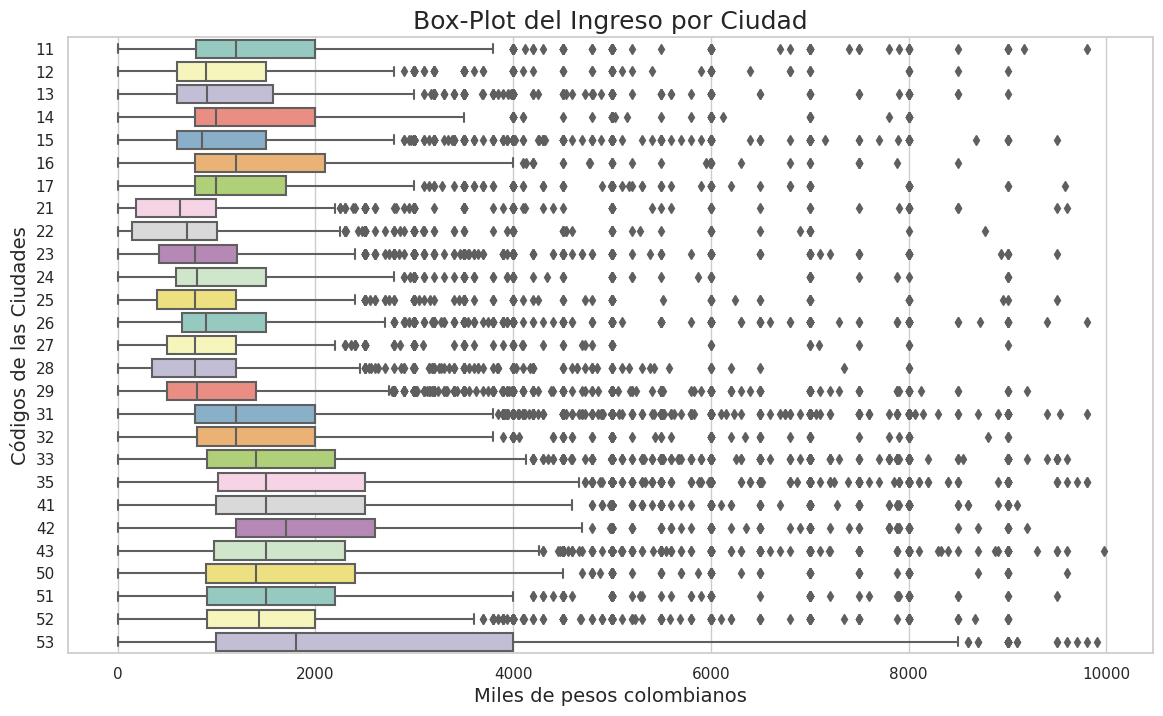

In [90]:
# Filtrar datos para ingresos menores a 10,000
datos_filtrados = datos.query('Ingreso < 10000')

# Crear el gráfico de caja
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='Ingreso', y='Ciudad', data=datos_filtrados, orient='h', palette="Set3")
ax.set_title('Box-Plot del Ingreso por Ciudad', fontsize=18)
ax.set_xlabel('Miles de pesos colombianos', fontsize=14)
ax.set_ylabel('Códigos de las Ciudades', fontsize=14)

# Mostrar el gráfico
plt.show()